### Import Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)


### Load Real NFL Game Data

In [42]:
url = 'https://raw.githubusercontent.com/nflverse/nfldata/master/data/games.csv'
data = pd.read_csv(url)
data.sample(5)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7548 entries, 0 to 7547
Data columns (total 46 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_id           7548 non-null   object 
 1   season            7548 non-null   int64  
 2   game_type         7548 non-null   object 
 3   week              7548 non-null   int64  
 4   gameday           7548 non-null   object 
 5   weekday           7548 non-null   object 
 6   gametime          7289 non-null   object 
 7   away_team         7548 non-null   object 
 8   away_score        7276 non-null   float64
 9   home_team         7548 non-null   object 
 10  home_score        7276 non-null   float64
 11  location          7548 non-null   object 
 12  result            7276 non-null   float64
 13  total             7276 non-null   float64
 14  overtime          7276 non-null   float64
 15  old_game_id       7548 non-null   int64  
 16  gsis              7276 non-null   float64


### Filter to Completed Regular-Season Games

### Keep only regular season games

In [43]:
data = data[data['game_type'] == 'REG']

### Drop games that have not been played yet 

In [44]:
data = data.dropna(subset=['home_score', 'away_score'])

## Remove ties and create the target variable

### Drop the small number of small games

In [45]:
data = data[data['home_score'] != data['away_score']]

### Create the target: 1 = home team won, 0 = home team lost

In [46]:
data['home_win'] = (data['home_score'] > data['away_score']).astype(int)

data['home_win'].value_counts()

home_win
1    3905
0    3047
Name: count, dtype: int64

## Clean messy values before modeling

### fill missing weather (most domes have no outdoor weather

In [47]:
data['temp'] = data['temp'].fillna(data['temp'].median())
data['wind'] = data['wind'].fillna(0)

### strip hidden whitespaces "grass" and "grass " aren't treated as two different categories

In [48]:
data['surface'] = data['surface'].str.strip()
data['surface'] = data['surface'].fillna(data['surface'].mode()[0])

### Select Features, focus on thing known before kickoff, not before. 

In [49]:
features_cols = ['spread_line', 'total_line', 'div_game', 'home_rest', 'away_rest', 
                 'temp', 'wind', 'roof', 'surface']
model_data = data[features_cols + ['home_win']].copy()

In [50]:
model_data = pd.get_dummies(model_data, columns=['roof', 'surface'], drop_first=True)

X = model_data.drop(columns=['home_win']) # feature
y = model_data['home_win'] # target

## Train, Test, Split (with stratification)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Scale the numeric feature

In [52]:
numeric_cols = ['spread_line', 'total_line', 'home_rest', 'away_rest', 'temp', 'wind']

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Train a Logistic Regression Model

In [53]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Evaluate with Accuracy and a Classification Report

In [54]:
y_pred = model.predict(X_test)
y_proba =model.predict_proba(X_test)[:, 1] #probility of a home win

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6455787203450755
              precision    recall  f1-score   support

           0       0.62      0.51      0.56       610
           1       0.66      0.75      0.70       781

    accuracy                           0.65      1391
   macro avg       0.64      0.63      0.63      1391
weighted avg       0.64      0.65      0.64      1391



### Visualize the Confusion Matrix

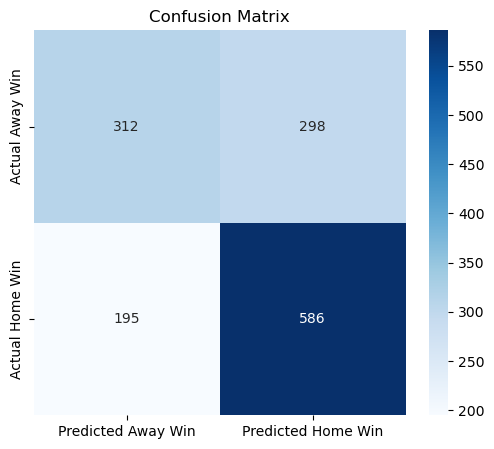

In [56]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Away Win', 'Predicted Home Win'],
            yticklabels=['Actual Away Win', 'Actual Home Win'])
plt.title('Confusion Matrix')
plt.show()

## Plot the ROC Curve and AUC Score

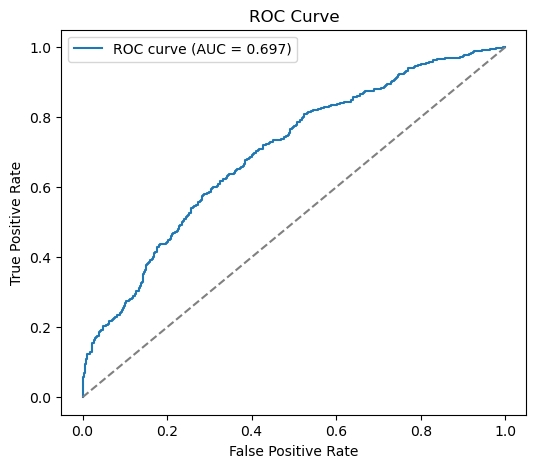

In [58]:
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray') # baseline = random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Examine which Features Matter Most

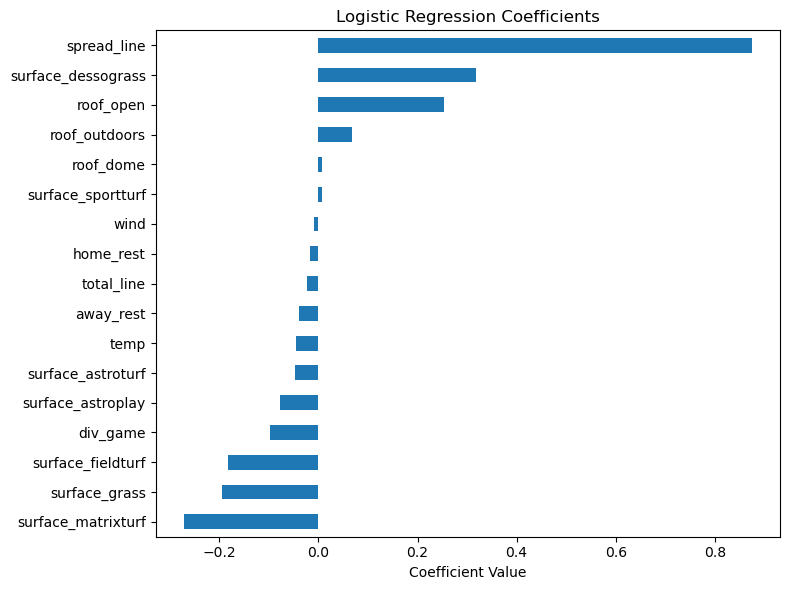

In [60]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
coefs.plot(kind='barh')
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()